In [43]:
# Notebook: Similar Artists
#
# Loads the most-rated artists by taking the union of user_songs (liked)
# and unliked_songs (disliked), then computes avg like rate and total
# rating count per artist.  Used as the basis for computing similar artists.

import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
%matplotlib inline

# Connect to the museiq database and expose `connection`, `engine`, and `DB`
%run db.py

<Figure size 640x480 with 0 Axes>

In [44]:
def get_most_rated_artists(start_date, min_ratings=20):
    """
    Load artists ranked by total number of ratings (likes + dislikes).

    Takes the union of:
    - user_songs   (liked=1, type=1 users only)
    - unliked_songs (liked=0)

    Returns a list of dicts with: artist_id, artist, cnt, avg_liked,
    num_fans, pop_decile — ordered by cnt desc.
    """
    sql = """
        SELECT artist_id,
               MAX(artist)     AS artist,
               COUNT(*)        AS cnt,
               AVG(liked)      AS avg_liked,
               MAX(num_fans)   AS num_fans,
               MAX(pop_decile) AS pop_decile
        FROM (
            SELECT c.artist_id, a.name AS artist, us.user_id, 1 AS liked,
                   a.num_fans, a.pop_decile
            FROM user_songs us
            INNER JOIN users u   ON us.user_id  = u.id
            INNER JOIN catalog c ON us.song_id  = c.id
            INNER JOIN artists a ON c.artist_id = a.id
            WHERE us.seq != 1
              AND us.timestamp >= '%s'

            UNION ALL

            SELECT c.artist_id, a.name AS artist, us.user_id, 0 AS liked,
                   a.num_fans, a.pop_decile
            FROM unliked_songs us
            INNER JOIN catalog c ON us.song_id  = c.id
            INNER JOIN artists a ON c.artist_id = a.id
            WHERE us.timestamp >= '%s'
        ) t
        GROUP BY artist_id
        HAVING cnt >= %s
        ORDER BY cnt DESC
    """ % (start_date, start_date, min_ratings)

    artists = DB.fetch(sql)
    print(f"Loaded {len(artists):,} artists with >= {min_ratings} ratings")
    return artists

In [5]:
# Load artists rated since 2025 with at least 20 ratings
artists = get_most_rated_artists('2020-01-01', min_ratings=100)

Loaded 7,977 artists with >= 100 ratings


In [12]:
# Preview the top artists by rating volume
df = pd.DataFrame(artists)
df.head(20)

,artist_id,artist,cnt,avg_liked,num_fans,pop_decile
0,539,Taylor Swift,22030,0.6258,61628126.0,100
1,121,Green Day,20546,0.6328,19256220.0,78
2,1431,My Chemical Romance,19249,0.6020,11693272.0,77
3,27,Michael Jackson,17829,0.6129,27032416.0,82
4,2,The Beatles,17443,0.6581,24722766.0,83
5,998,Ed Sheeran,15566,0.6035,80905914.0,90
6,1776,Adele,15549,0.5998,67803179.0,85
7,276,Chris Brown,15046,0.5904,36607489.0,87
8,903,Justin Bieber,14749,0.6076,89015332.0,90
9,171,Coldplay,14405,0.5737,61866643.0,88


In [15]:
def get_song_agreement(song_id_a, song_id_b):
    """
    Compute the probability that a user agrees on two songs —
    i.e., P(both liked or both disliked) among users who rated both.

    Returns a dict with:
      shared_users  — number of users who rated both songs
      p_agreement   — fraction who gave the same rating to both
    """
    sql = """
        SELECT
            COUNT(*)                                     AS shared_users,
            AVG(IF(a.liked = b.liked, 1, 0))             AS p_agreement
        FROM (
            SELECT user_id, 1 AS liked FROM user_songs   WHERE song_id = %s
            UNION ALL
            SELECT user_id, 0 AS liked FROM unliked_songs WHERE song_id = %s
        ) a
        INNER JOIN (
            SELECT user_id, 1 AS liked FROM user_songs   WHERE song_id = %s
            UNION ALL
            SELECT user_id, 0 AS liked FROM unliked_songs WHERE song_id = %s
        ) b ON a.user_id = b.user_id
    """ % (song_id_a, song_id_a, song_id_b, song_id_b)

    return DB.fetch(sql)[0]

In [25]:
def get_most_rated_song(artist_id):
    """Return the song_id with the most ratings (likes + dislikes) for a given artist."""
    sql = """
        SELECT song_id, MAX(title) AS title, COUNT(*) AS cnt
        FROM (
            SELECT us.song_id, c.title
            FROM user_songs us
            INNER JOIN catalog c ON us.song_id = c.id
            WHERE c.artist_id = %s
            UNION ALL
            SELECT us.song_id, c.title
            FROM unliked_songs us
            INNER JOIN catalog c ON us.song_id = c.id
            WHERE c.artist_id = %s
        ) t
        GROUP BY song_id
        ORDER BY cnt DESC
        LIMIT 1
    """ % (artist_id, artist_id)

    return DB.fetch(sql)[0]

In [26]:
import matplotlib.pyplot as plt
import numpy as np

top20 = artists[:20]

# Get the most-rated song for each artist
top20_songs = []
for a in top20:
    song = get_most_rated_song(a['artist_id'])
    top20_songs.append({'artist': a['artist'], 'song_id': song['song_id'], 'title': song['title']})
    print(f"{a['artist']:30s}  →  {song['title']}  (n={song['cnt']})")

labels = [s['artist'] for s in top20_songs]
n = len(top20_songs)

Taylor Swift                    →  Welcome To New York  (n=710)
Green Day                       →  Boulevard of Broken Dreams  (n=1869)
My Chemical Romance             →  Welcome to the Black Parade  (n=1523)
Michael Jackson                 →  Thriller  (n=1777)
The Beatles                     →  Come Together  (n=831)
Ed Sheeran                      →  Shape of You  (n=1440)
Adele                           →  Rolling in the Deep  (n=2603)
Chris Brown                     →  Loyal  (n=1078)
Justin Bieber                   →  Sorry  (n=1277)
Coldplay                        →  Clocks  (n=2458)
Rihanna                         →  Umbrella  (n=1379)
Radiohead                       →  Creep  (n=1112)
Kanye West                      →  Power  (n=989)
Post Malone                     →  Better Now  (n=1826)
Drake                           →  God's Plan  (n=1106)
The Weeknd                      →  Starboy  (n=1287)
Eminem                          →  Lose Yourself  (n=1392)
Beyoncé                

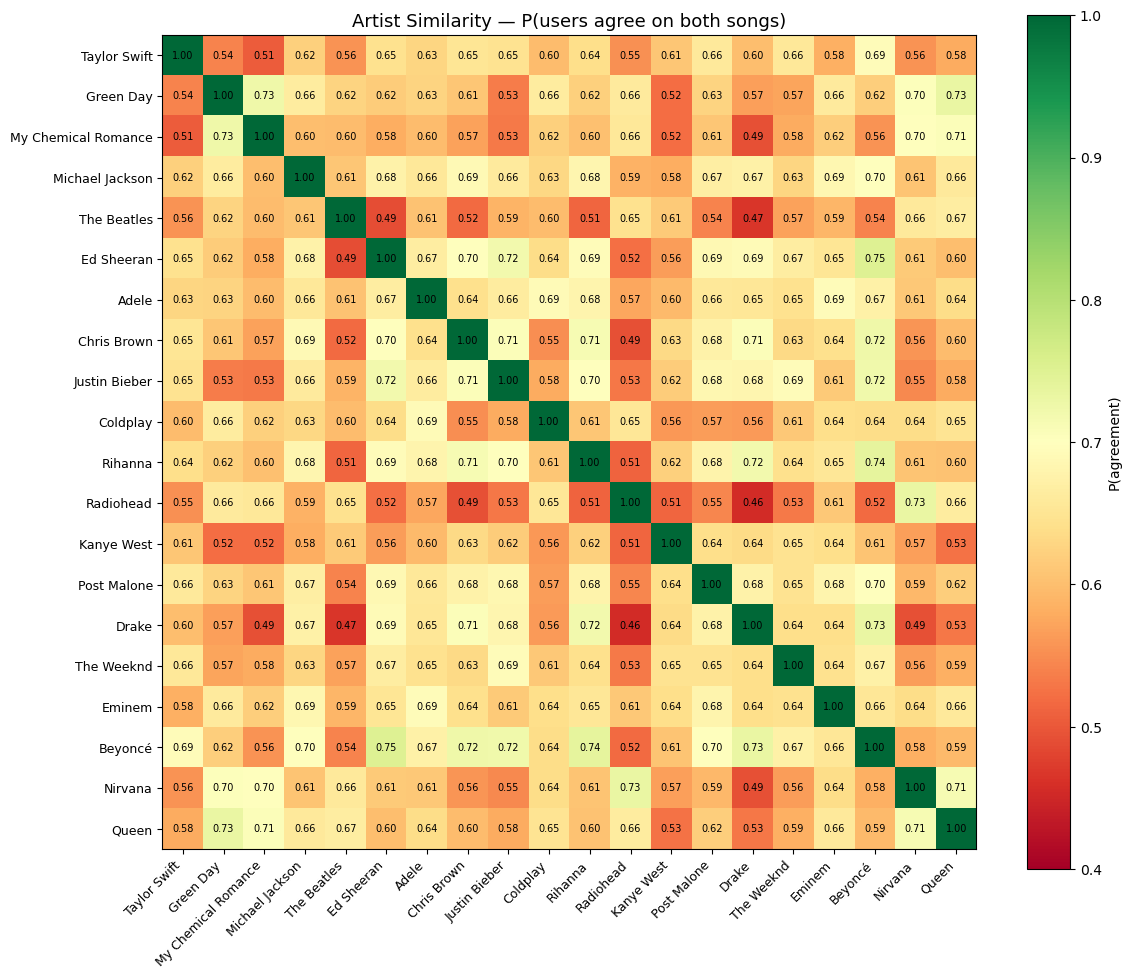

In [27]:
# Compute pairwise agreement matrix
sim = np.zeros((n, n))

for i in range(n):
    sim[i, i] = 1.0  # perfect agreement with itself
    for j in range(i + 1, n):
        result = get_song_agreement(top20_songs[i]['song_id'], top20_songs[j]['song_id'])
        p = float(result['p_agreement']) if result['shared_users'] else 0.5
        sim[i, j] = p
        sim[j, i] = p

# Plot heatmap
fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(sim, vmin=0.4, vmax=1.0, cmap='RdYlGn')

ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(labels, fontsize=9)

# Annotate cells
for i in range(n):
    for j in range(n):
        ax.text(j, i, f'{sim[i, j]:.2f}', ha='center', va='center',
                fontsize=7, color='black')

plt.colorbar(im, ax=ax, label='P(agreement)')
ax.set_title('Artist Similarity — P(users agree on both songs)', fontsize=13)
plt.tight_layout()
plt.show()

In [28]:
def plot_artist_similarity_heatmap(artist_ids):
    """
    Given a list of artist_ids, fetch each artist's most-rated song,
    compute pairwise P(agreement), and display a heatmap.
    """
    # Build a lookup from artist_id -> name using the already-loaded df
    id_to_name = df.set_index('artist_id')['artist'].to_dict()

    songs = []
    for aid in artist_ids:
        song = get_most_rated_song(aid)
        name = id_to_name.get(aid, str(aid))
        songs.append({'artist': name, 'song_id': song['song_id'], 'title': song['title']})
        print(f"{name:30s}  →  {song['title']}  (n={song['cnt']})")

    n = len(songs)
    labels = [s['artist'] for s in songs]

    sim = np.zeros((n, n))
    for i in range(n):
        sim[i, i] = 1.0
        for j in range(i + 1, n):
            result = get_song_agreement(songs[i]['song_id'], songs[j]['song_id'])
            p = float(result['p_agreement']) if result['shared_users'] else 0.5
            sim[i, j] = p
            sim[j, i] = p

    fig, ax = plt.subplots(figsize=(max(8, n), max(6, n - 2)))
    im = ax.imshow(sim, vmin=0.4, vmax=1.0, cmap='RdYlGn')

    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(labels, fontsize=9)

    for i in range(n):
        for j in range(n):
            ax.text(j, i, f'{sim[i, j]:.2f}', ha='center', va='center',
                    fontsize=7, color='black')

    plt.colorbar(im, ax=ax, label='P(agreement)')
    ax.set_title('Artist Similarity — P(users agree on both songs)', fontsize=13)
    plt.tight_layout()
    plt.show()

    return sim, labels


# Example: heatmap for a custom list of artist_ids
# plot_artist_similarity_heatmap([539, 121, 1431, 27, 2])

In [31]:
def plot_genre_heatmap(genre, top_n=5, start_date='2020-01-01', min_ratings=100):
    """
    Find the top_n most-rated artists in a genre and plot their similarity heatmap.
    Uses the artist_genre table to filter by genre.
    """
    sql = """
        SELECT t.artist_id,
               MAX(a.name)      AS artist,
               COUNT(*)         AS cnt
        FROM (
            SELECT c.artist_id, us.user_id
            FROM user_songs us
            INNER JOIN catalog c ON us.song_id = c.id
            WHERE us.timestamp >= '%s'
            UNION ALL
            SELECT c.artist_id, us.user_id
            FROM unliked_songs us
            INNER JOIN catalog c ON us.song_id = c.id
            WHERE us.timestamp >= '%s'
        ) t
        INNER JOIN artists a       ON t.artist_id = a.id
        INNER JOIN artist_genre ag ON t.artist_id = ag.artist_id
        WHERE ag.genre = '%s'
        GROUP BY t.artist_id
        HAVING cnt >= %s
        ORDER BY cnt DESC
        LIMIT %s
    """ % (start_date, start_date, genre, min_ratings, top_n)

    rows = DB.fetch(sql)
    if not rows:
        print(f"No artists found for genre '{genre}'")
        return

    print(f"Top {len(rows)} artists in '{genre}':")
    for r in rows:
        print(f"  {r['artist']:30s}  ({r['cnt']:,} ratings)")

    artist_ids = [r['artist_id'] for r in rows]
    return plot_artist_similarity_heatmap(artist_ids)


# Example:
# plot_genre_heatmap('rock')

Gorillaz                        →  Feel Good Inc.  (n=2352)
Lorde                           →  Royals  (n=1425)
The Cure                        →  Just Like Heaven  (n=1207)
Twenty One Pilots               →  Stressed Out  (n=682)
Katy Perry                      →  I Kissed a Girl  (n=476)
KomPROmaT                       →  Einfach da sein  (n=189)
Morcheeba                       →  The Sea  (n=130)
Orelsan                         →  Basique  (n=150)
Ásgeir                          →  Nothing  (n=100)
Sprints                         →  Little Fix  (n=80)


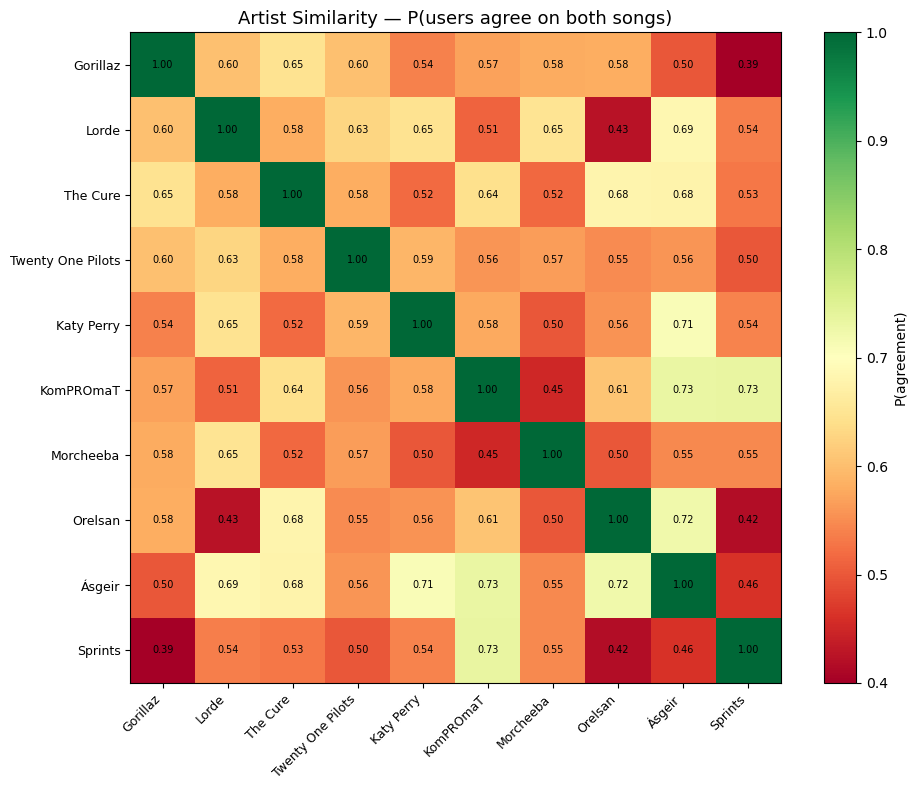

(array([[1.    , 0.6039, 0.6468, 0.602 , 0.5405, 0.5695, 0.5797, 0.5821,
         0.5   , 0.3864],
        [0.6039, 1.    , 0.5827, 0.6286, 0.6478, 0.5102, 0.6494, 0.4255,
         0.6852, 0.5366],
        [0.6468, 0.5827, 1.    , 0.5823, 0.5176, 0.6435, 0.5161, 0.6792,
         0.678 , 0.5294],
        [0.602 , 0.6286, 0.5823, 1.    , 0.5904, 0.5581, 0.5652, 0.5484,
         0.5577, 0.5   ],
        [0.5405, 0.6478, 0.5176, 0.5904, 1.    , 0.5763, 0.5   , 0.5556,
         0.7073, 0.5417],
        [0.5695, 0.5102, 0.6435, 0.5581, 0.5763, 1.    , 0.45  , 0.6071,
         0.7317, 0.7333],
        [0.5797, 0.6494, 0.5161, 0.5652, 0.5   , 0.45  , 1.    , 0.5   ,
         0.5455, 0.5455],
        [0.5821, 0.4255, 0.6792, 0.5484, 0.5556, 0.6071, 0.5   , 1.    ,
         0.7222, 0.4167],
        [0.5   , 0.6852, 0.678 , 0.5577, 0.7073, 0.7317, 0.5455, 0.7222,
         1.    , 0.4615],
        [0.3864, 0.5366, 0.5294, 0.5   , 0.5417, 0.7333, 0.5455, 0.4167,
         0.4615, 1.    ]]),
 ['Goril

In [48]:
rows = DB.fetch("""
    select artist_id,max(num_likes+num_dislikes+num_superlikes) as cnt
    from piki_score
    where artist_id in 
    (SELECT artist_id FROM shows s
    INNER JOIN artists a ON s.artist_id = a.id
    WHERE venue = 'paleo' AND date > '2026-07-01'
    )
    group by artist_id
    order by cnt desc limit 10
""")
#print(rows)
paleo_ids = [r['artist_id'] for r in rows]
plot_artist_similarity_heatmap(paleo_ids)

Katy Perry                      →  I Kissed a Girl  (n=476)
Gorillaz                        →  Feel Good Inc.  (n=2351)
Twenty One Pilots               →  Stressed Out  (n=682)
Lorde                           →  Royals  (n=1425)
The Cure                        →  Just Like Heaven  (n=1207)
Orelsan                         →  Basique  (n=150)
Timmy Trumpet                   →  Freaks - Radio Edit  (n=31)
717053                          →  Est-ce que tu m'aimes ? - Pilule bleue  (n=27)
Bob Sinclar                     →  World Hold On - FISHER Rework  (n=36)
1127522                         →  Yamê - Bécane | A COLORS SHOW  (n=33)
Zaz                             →  Je veux  (n=46)
37053                           →  Moïse  (n=36)
Morcheeba                       →  The Sea  (n=130)
Asaf Avidan                     →  My Tunnels Are Long and Dark These Days  (n=34)
Vanessa Paradis                 →  Joe le taxi  (n=16)
96060                           →  Kavin Kom  (n=7)
Ásgeir                  

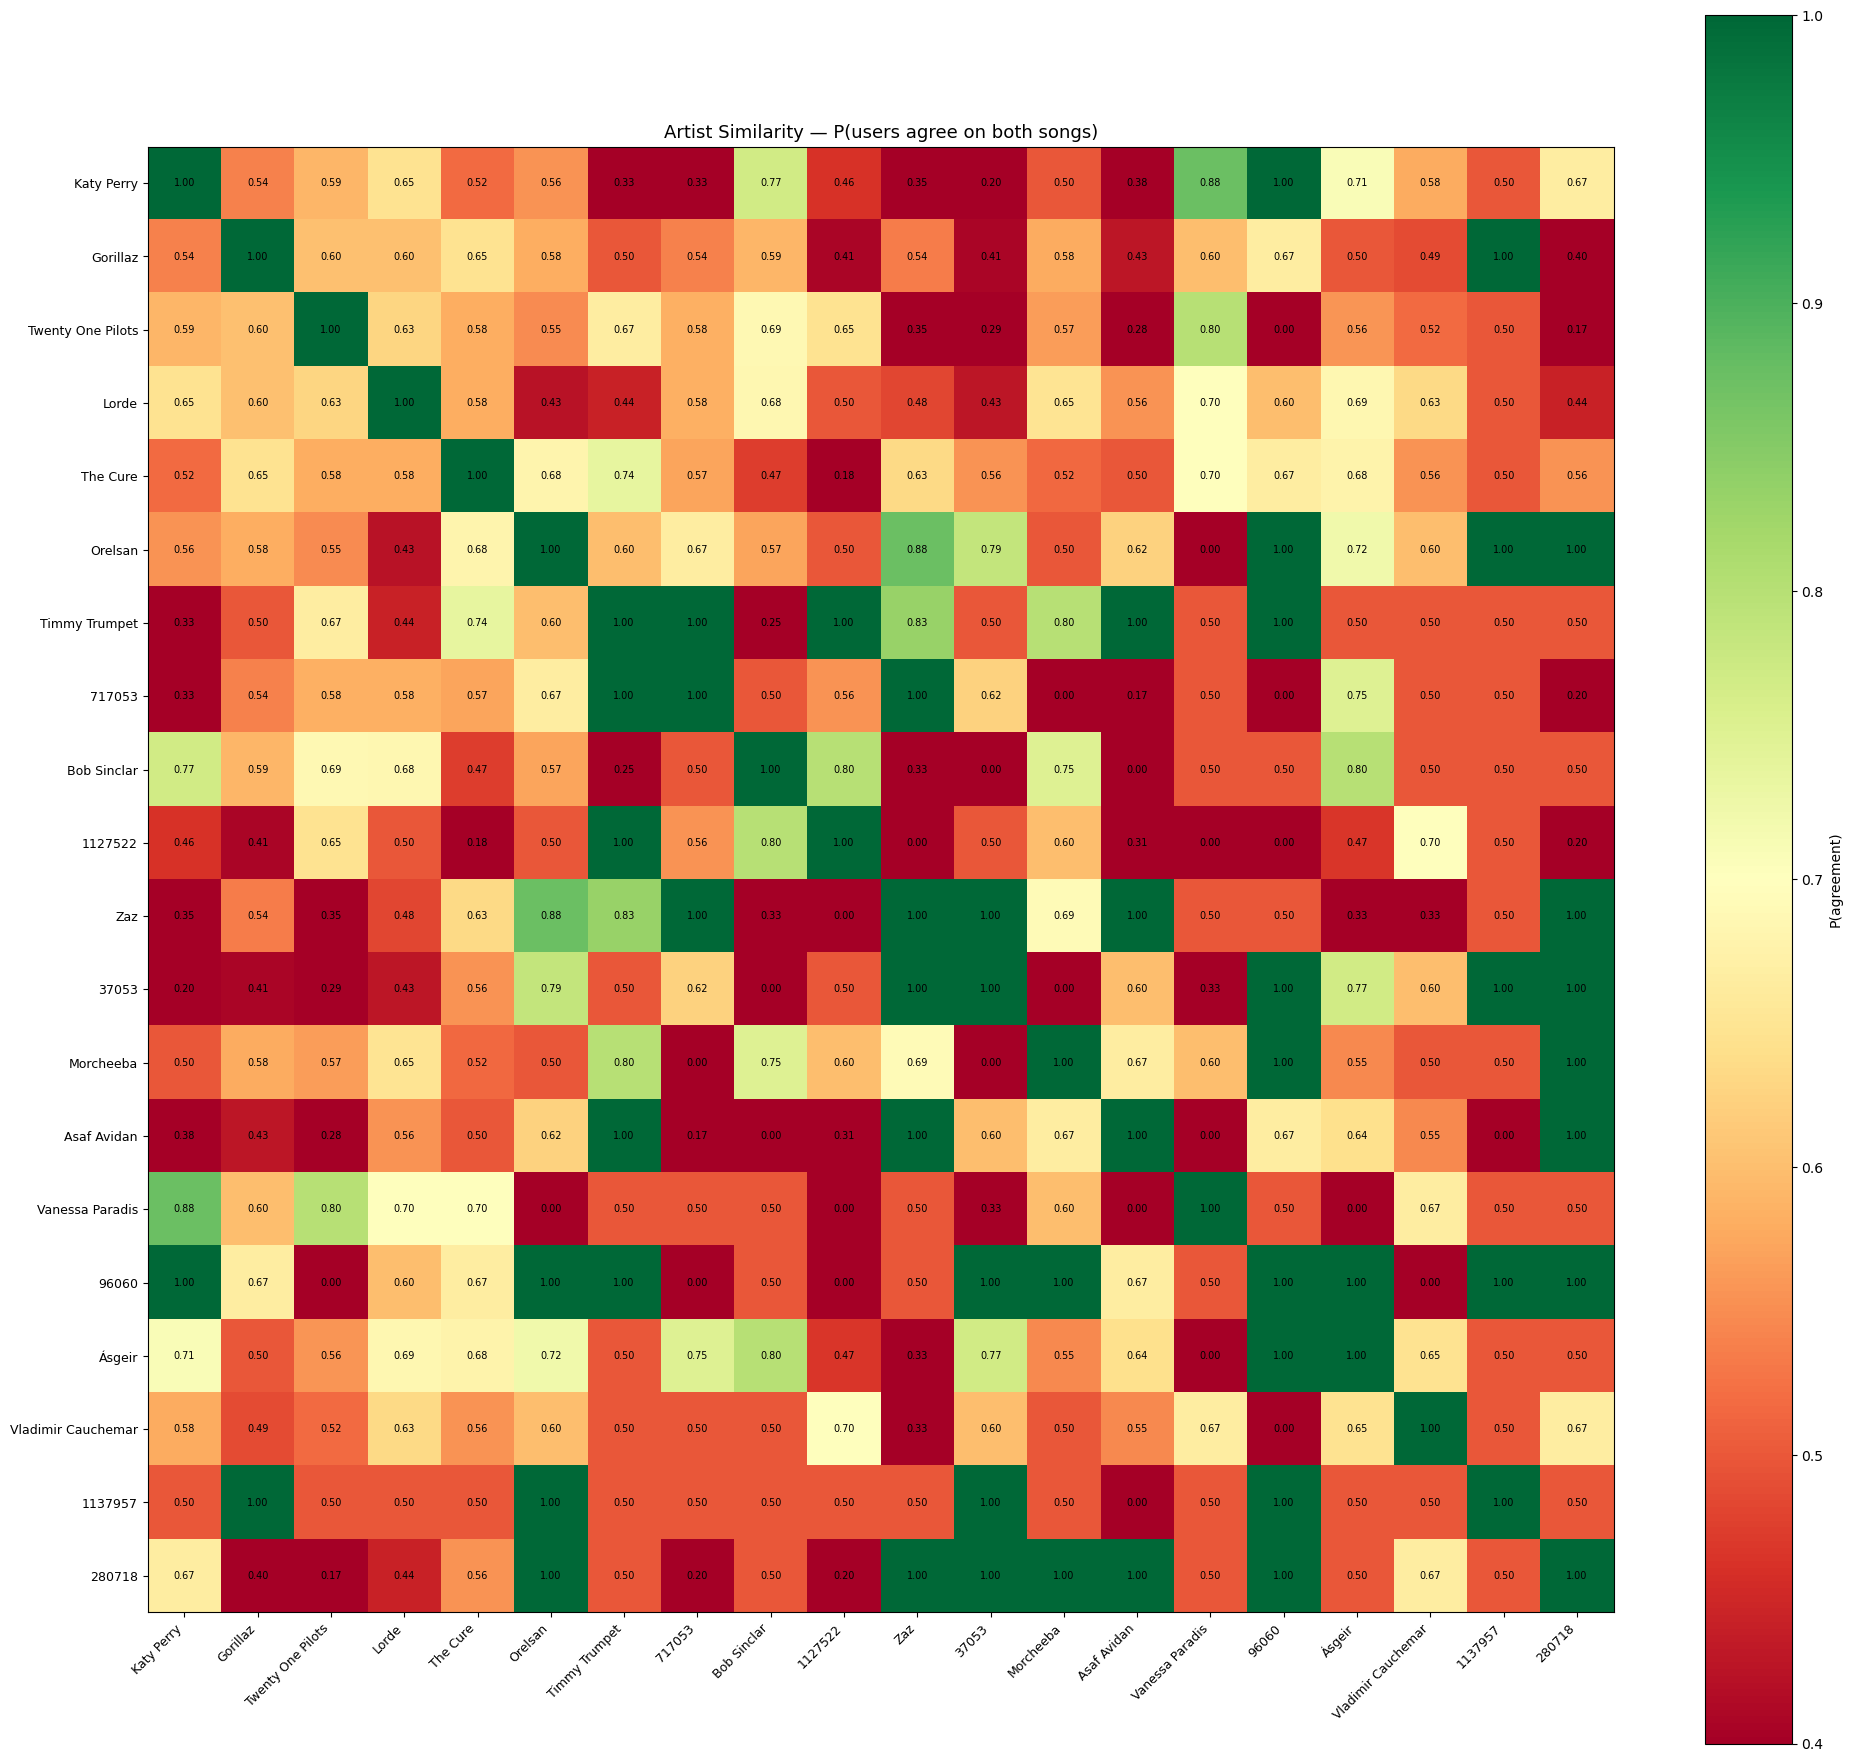

(array([[1.    , 0.5405, 0.5904, 0.6478, 0.5176, 0.5556, 0.3333, 0.3333,
         0.7692, 0.4615, 0.35  , 0.2   , 0.5   , 0.3846, 0.875 , 1.    ,
         0.7073, 0.5789, 0.5   , 0.6667],
        [0.5405, 1.    , 0.602 , 0.6039, 0.6468, 0.5821, 0.5   , 0.5385,
         0.5909, 0.4091, 0.5357, 0.4091, 0.5797, 0.4286, 0.6   , 0.6667,
         0.5   , 0.4878, 1.    , 0.4   ],
        [0.5904, 0.602 , 1.    , 0.6286, 0.5823, 0.5484, 0.6667, 0.5833,
         0.6875, 0.6471, 0.3478, 0.2857, 0.5652, 0.2778, 0.8   , 0.    ,
         0.5577, 0.5185, 0.5   , 0.1667],
        [0.6478, 0.6039, 0.6286, 1.    , 0.5827, 0.4255, 0.4444, 0.5833,
         0.6842, 0.5   , 0.4839, 0.4286, 0.6494, 0.5556, 0.7   , 0.6   ,
         0.6852, 0.6333, 0.5   , 0.4444],
        [0.5176, 0.6468, 0.5823, 0.5827, 1.    , 0.6792, 0.7368, 0.5714,
         0.4737, 0.1765, 0.6333, 0.5556, 0.5161, 0.5   , 0.7   , 0.6667,
         0.678 , 0.5556, 0.5   , 0.5556],
        [0.5556, 0.5821, 0.5484, 0.4255, 0.6792, 1.    , 0.6

In [39]:
rows = DB.fetch("""
    SELECT artist_id FROM shows s
    INNER JOIN artists a ON s.artist_id = a.id
    WHERE venue = 'paleo' AND date > '2026-07-01'
    ORDER BY pop_decile DESC
    LIMIT 20
""")

paleo_ids = [r['artist_id'] for r in rows]
plot_artist_similarity_heatmap(paleo_ids)

Taylor Swift                    →  Welcome To New York  (n=710)
Green Day                       →  Boulevard of Broken Dreams  (n=1869)
My Chemical Romance             →  Welcome to the Black Parade  (n=1523)
Michael Jackson                 →  Thriller  (n=1777)
The Beatles                     →  Come Together  (n=831)


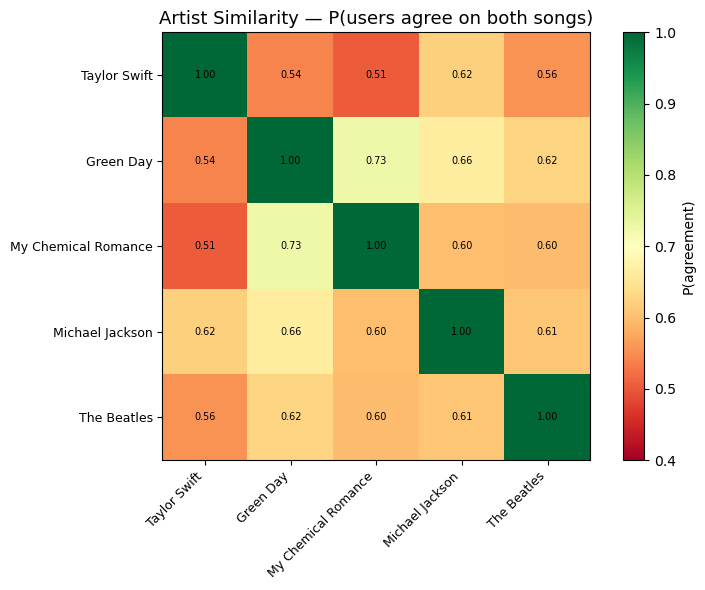

(array([[1.    , 0.5417, 0.5053, 0.621 , 0.5561],
        [0.5417, 1.    , 0.7253, 0.6641, 0.625 ],
        [0.5053, 0.7253, 1.    , 0.5997, 0.599 ],
        [0.621 , 0.6641, 0.5997, 1.    , 0.6092],
        [0.5561, 0.625 , 0.599 , 0.6092, 1.    ]]),
 ['Taylor Swift',
  'Green Day',
  'My Chemical Romance',
  'Michael Jackson',
  'The Beatles'])

In [29]:
plot_artist_similarity_heatmap([539, 121, 1431, 27, 2])

Top 8 artists in 'Rock':
  Queen                           (12,718 ratings)
  The Killers                     (10,759 ratings)
  Imagine Dragons                 (7,954 ratings)
  Arctic Monkeys                  (7,692 ratings)
  Twenty One Pilots               (7,257 ratings)
  Muse                            (7,007 ratings)
  The Cure                        (6,726 ratings)
  Portugal. The Man               (6,469 ratings)
Queen                           →  Bohemian Rhapsody  (n=1722)
The Killers                     →  Mr. Brightside  (n=3343)
Imagine Dragons                 →  Believer  (n=495)
Arctic Monkeys                  →  Do I Wanna Know? (Legendado/tradução)  (n=692)
Twenty One Pilots               →  Stressed Out  (n=682)
Muse                            →  Supermassive Black Hole  (n=681)
The Cure                        →  Just Like Heaven  (n=1207)
Portugal. The Man               →  Feel It Still  (n=2963)


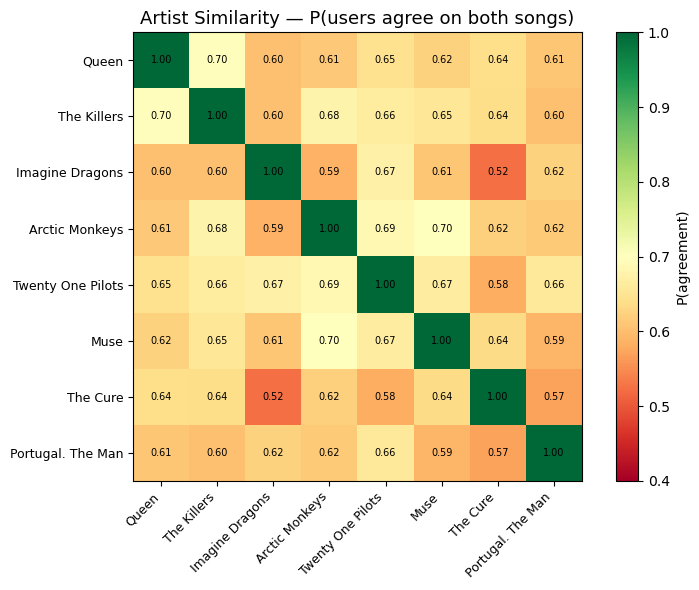

(array([[1.    , 0.6968, 0.6024, 0.6115, 0.6453, 0.6244, 0.6395, 0.6093],
        [0.6968, 1.    , 0.6032, 0.6788, 0.664 , 0.6534, 0.6386, 0.6026],
        [0.6024, 0.6032, 1.    , 0.5867, 0.6735, 0.6105, 0.5219, 0.6247],
        [0.6115, 0.6788, 0.5867, 1.    , 0.686 , 0.7012, 0.6212, 0.6156],
        [0.6453, 0.664 , 0.6735, 0.686 , 1.    , 0.6667, 0.5823, 0.6567],
        [0.6244, 0.6534, 0.6105, 0.7012, 0.6667, 1.    , 0.6361, 0.5917],
        [0.6395, 0.6386, 0.5219, 0.6212, 0.5823, 0.6361, 1.    , 0.571 ],
        [0.6093, 0.6026, 0.6247, 0.6156, 0.6567, 0.5917, 0.571 , 1.    ]]),
 ['Queen',
  'The Killers',
  'Imagine Dragons',
  'Arctic Monkeys',
  'Twenty One Pilots',
  'Muse',
  'The Cure',
  'Portugal. The Man'])

In [37]:
plot_genre_heatmap('Rock', top_n=8, start_date='2020-01-01', min_ratings=100)

Top 5 artists in 'Electronic':
  The Avalanches                  (3,880 ratings)
  Floating Points                 (3,879 ratings)
  Connan Mockasin                 (3,608 ratings)
  Hot Chip                        (3,317 ratings)
  Thom Yorke                      (2,903 ratings)
The Avalanches                  →  Since I Left You  (n=383)
Floating Points                 →  LesAlpx  (n=571)
Connan Mockasin                 →  Feelin' Lovely  (n=546)
Hot Chip                        →  I Feel Better (Adam Smith Bootleg)  (n=573)
Thom Yorke                      →  Last I Heard (...He Was Circling the Drain)  (n=601)


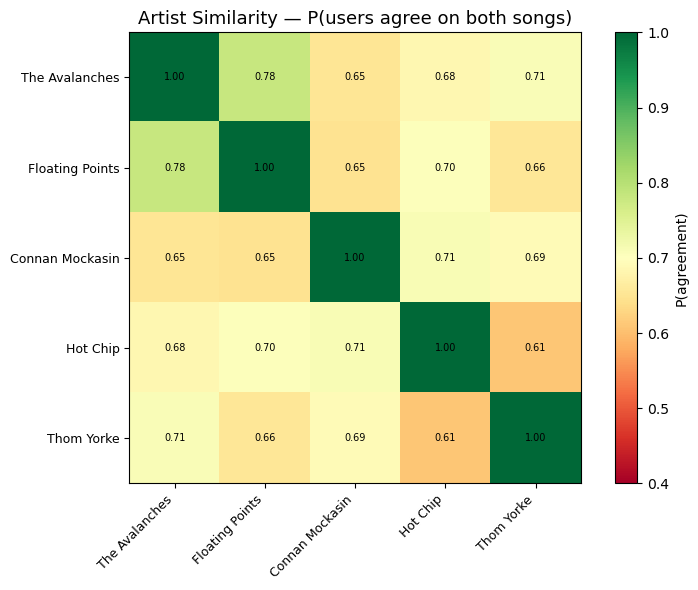

(array([[1.    , 0.7797, 0.6512, 0.6842, 0.7083],
        [0.7797, 1.    , 0.6479, 0.7036, 0.655 ],
        [0.6512, 0.6479, 1.    , 0.7111, 0.6908],
        [0.6842, 0.7036, 0.7111, 1.    , 0.6103],
        [0.7083, 0.655 , 0.6908, 0.6103, 1.    ]]),
 ['The Avalanches',
  'Floating Points',
  'Connan Mockasin',
  'Hot Chip',
  'Thom Yorke'])

In [33]:
plot_genre_heatmap('Electronic', top_n=5, start_date='2020-01-01', min_ratings=100)

Top 5 artists in 'hip hop':
  Drake                           (15,119 ratings)
  Eminem                          (14,096 ratings)
  Kendrick Lamar                  (12,260 ratings)
  2Pac                            (11,386 ratings)
  50 Cent                         (7,149 ratings)
Drake                           →  God's Plan  (n=1106)
Eminem                          →  Lose Yourself  (n=1392)
Kendrick Lamar                  →  HUMBLE.  (n=1620)
2Pac                            →  Dear Mama  (n=1211)
50 Cent                         →  Candy Shop  (n=1431)


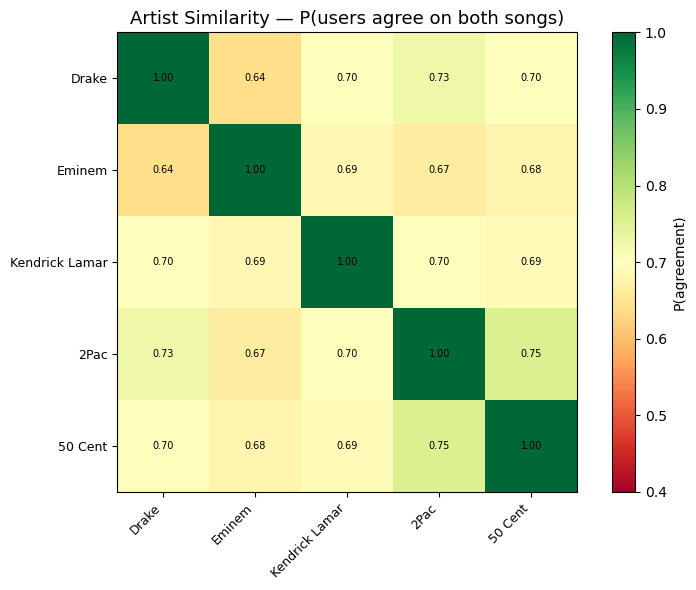

(array([[1.    , 0.6396, 0.698 , 0.7251, 0.7031],
        [0.6396, 1.    , 0.6861, 0.6667, 0.6792],
        [0.698 , 0.6861, 1.    , 0.7025, 0.6918],
        [0.7251, 0.6667, 0.7025, 1.    , 0.7537],
        [0.7031, 0.6792, 0.6918, 0.7537, 1.    ]]),
 ['Drake', 'Eminem', 'Kendrick Lamar', '2Pac', '50 Cent'])

In [34]:
plot_genre_heatmap('hip hop', top_n=5, start_date='2020-01-01', min_ratings=100)

Top 5 artists in 'pop':
  Taylor Swift                    (24,931 ratings)
  Michael Jackson                 (20,336 ratings)
  Ed Sheeran                      (18,594 ratings)
  Chris Brown                     (17,819 ratings)
  Adele                           (17,702 ratings)
Taylor Swift                    →  Welcome To New York  (n=710)
Michael Jackson                 →  Thriller  (n=1777)
Ed Sheeran                      →  Shape of You  (n=1440)
Chris Brown                     →  Loyal  (n=1078)
Adele                           →  Rolling in the Deep  (n=2603)


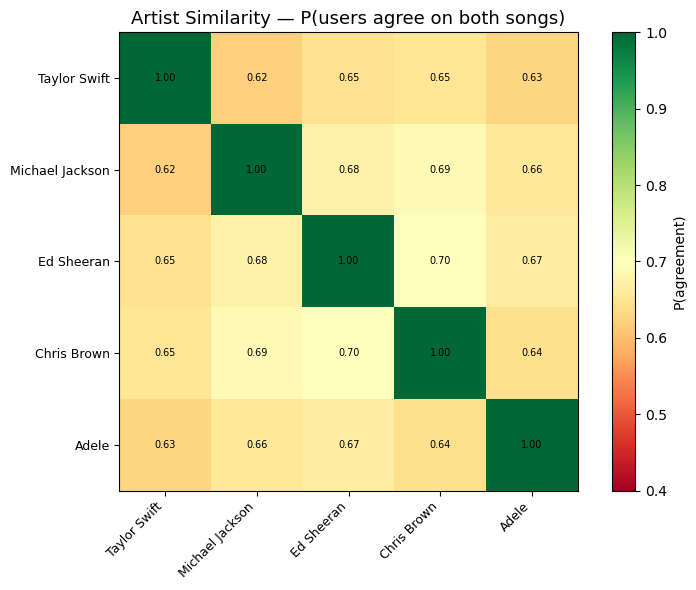

(array([[1.    , 0.621 , 0.6455, 0.653 , 0.6282],
        [0.621 , 1.    , 0.6751, 0.6892, 0.657 ],
        [0.6455, 0.6751, 1.    , 0.7006, 0.6653],
        [0.653 , 0.6892, 0.7006, 1.    , 0.6435],
        [0.6282, 0.657 , 0.6653, 0.6435, 1.    ]]),
 ['Taylor Swift', 'Michael Jackson', 'Ed Sheeran', 'Chris Brown', 'Adele'])

In [35]:
plot_genre_heatmap('pop', top_n=5, start_date='2020-01-01', min_ratings=100)

Top 10 artists in 'afrobeat':
  Burna Boy                       (11,580 ratings)
  Wizkid                          (10,881 ratings)
  Davido                          (9,401 ratings)
  Rema                            (7,621 ratings)
  Sauti Sol                       (6,238 ratings)
  TEms                            (5,868 ratings)
  Akon                            (4,493 ratings)
  Fireboy Dml                     (4,085 ratings)
  Ckay                            (3,987 ratings)
  Omah Lay                        (3,459 ratings)
Burna Boy                       →  Gbona  (n=1244)
Wizkid                          →  Fever  (n=891)
Davido                          →  Fall  (n=1009)
Rema                            →  Calm Down (with Selena Gomez)  (n=2218)
Sauti Sol                       →  Suzanna  (n=904)
TEms                            →  Free Mind  (n=1353)
Akon                            →  Don't Matter  (n=669)
Fireboy Dml                     →  Bandana  (n=1080)
Ckay                     

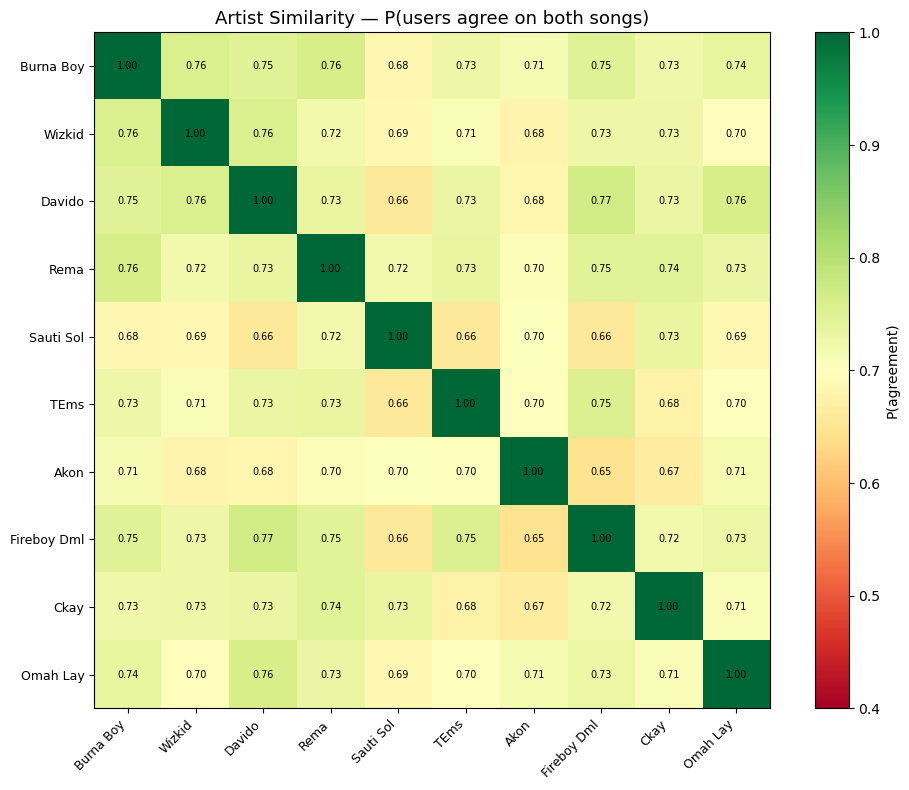

(array([[1.    , 0.7581, 0.7492, 0.7626, 0.6846, 0.7277, 0.7126, 0.747 ,
         0.7254, 0.7366],
        [0.7581, 1.    , 0.7567, 0.719 , 0.686 , 0.708 , 0.6808, 0.727 ,
         0.7276, 0.6976],
        [0.7492, 0.7567, 1.    , 0.7332, 0.6581, 0.7309, 0.6821, 0.7702,
         0.7308, 0.7628],
        [0.7626, 0.719 , 0.7332, 1.    , 0.7207, 0.7344, 0.705 , 0.7467,
         0.7448, 0.7324],
        [0.6846, 0.686 , 0.6581, 0.7207, 1.    , 0.6585, 0.7037, 0.6598,
         0.7347, 0.6863],
        [0.7277, 0.708 , 0.7309, 0.7344, 0.6585, 1.    , 0.7011, 0.7538,
         0.6762, 0.6983],
        [0.7126, 0.6808, 0.6821, 0.705 , 0.7037, 0.7011, 1.    , 0.648 ,
         0.6667, 0.7143],
        [0.747 , 0.727 , 0.7702, 0.7467, 0.6598, 0.7538, 0.648 , 1.    ,
         0.7204, 0.7298],
        [0.7254, 0.7276, 0.7308, 0.7448, 0.7347, 0.6762, 0.6667, 0.7204,
         1.    , 0.7073],
        [0.7366, 0.6976, 0.7628, 0.7324, 0.6863, 0.6983, 0.7143, 0.7298,
         0.7073, 1.    ]]),
 ['Burna

In [36]:
plot_genre_heatmap('afrobeat', top_n=10, start_date='2020-01-01', min_ratings=100)